# Reionisation observables from the electron power spectrum

In [1]:
import time
import matplotlib.pyplot as plt
from matplotlib import rc, colors
import numpy as np
from astropy import cosmology, units, constants
# import healpy as hp
import os
from scipy.interpolate import interp1d
from tqdm import tqdm

In [2]:
from theory import Pee_model
from utils import *

In [3]:
rc("font", **{"family": "serif", "serif": ["times new roman"], "size": 18})
rc("text", usetex=True)
rc("axes", linewidth=1.5)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
CL = 68
percentile1 = (100.-CL)/2.
percentile2 = CL+(100.-CL)/2.

In [6]:
ells = np.arange(50, 10000, step=250)

In [7]:
cos = cosmology.Planck18

## Consistent reionisation observables: power spectra

The `Pee_model` class allows you to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum, all following a consistent reionsation model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020.

In [8]:
model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=True, run_camb=True)

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0603
Running CAMB...


Text(0.5, 1.0, '$z=7.0$')

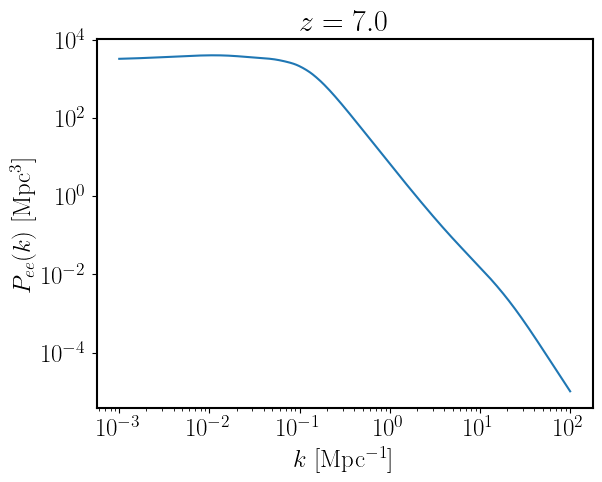

In [9]:
klog = np.logspace(-3, 2, 500)

plt.figure()
plt.loglog(klog, model.Pee(klog, model.zre_h))
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
plt.title(rf'$z={model.zre_h:.1f}$')

### Reionisation history

5.5 7.0


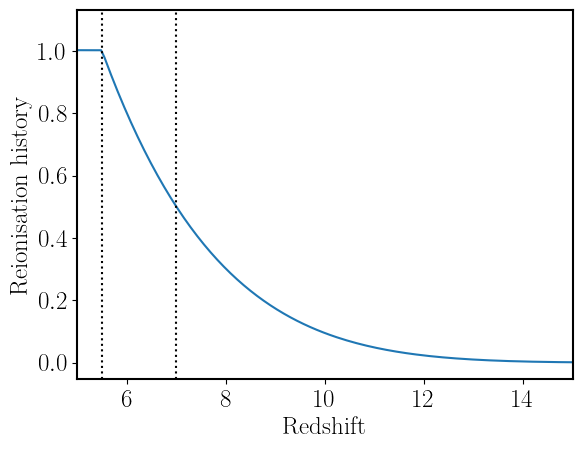

In [10]:
z = np.linspace(0, 20, 300)
print(model.zend_h, model.zre_h)
plt.figure()
plt.plot(z, model.xe(z)/1.08)
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')
plt.xlim(5, 15)
plt.axvline(model.zend_h, color='k', ls=':')
plt.axvline(model.zre_h, color='k', ls=':')

### kSZ power spectrum

To compute the kSZ power spectrum, use the `get_ksz` method. 
The following will output the kSZ power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [11]:
ksz_file = 'data/ref_ksz.txt'
if os.path.exists(ksz_file):
    ksz_ps = np.loadtxt(ksz_file, unpack=True)[1:].T
else:
    t0 = time.time()
    ksz_ps = model.get_ksz(ells=ells, signal='both', Dells=True)
    t1 = time.time()
    print(f'Computation took {t1-t0:.1f} seconds.')
    np.savetxt(ksz_file, np.c_[ells, ksz_ps], header='ells, Dells ksz')

In [12]:
i3000 = np.argmin(np.abs(3000-ells))
print(f'At l=3000, [atchy power = {ksz_ps[i3000, 0]:.1f} uK2, late-time power = {ksz_ps[i3000, 1]:.1f} uK2')

At l=3000, [atchy power = 1.2 uK2, late-time power = 3.1 uK2


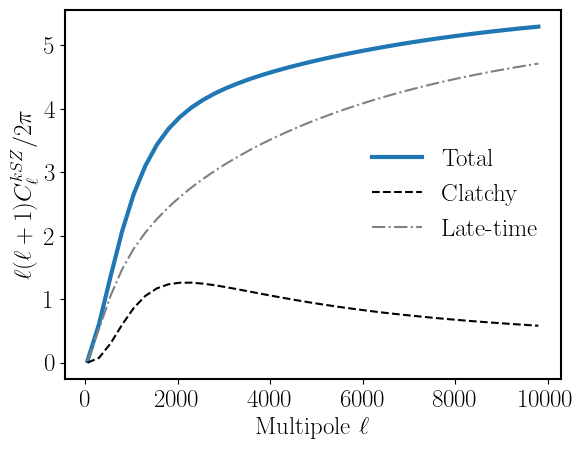

In [13]:
plt.figure()
plt.plot(ells, np.sum(ksz_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, ksz_ps[:, 0], label='Clatchy', ls='--', color='k')
plt.plot(ells, ksz_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### $\tau$ power spectrum

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [14]:
tau_file = 'data/ref_tau.txt'
if os.path.exists(tau_file):
    tau_ps = np.loadtxt(tau_file, unpack=True)[1:].T
else:
    t0 = time.time()
    tau_ps = model.get_tau(ells=ells, signal='both', Dells=True)
    t1 = time.time()
    print(f'Computation took {t1-t0:.1f} seconds.')
    np.savetxt(tau_file, np.c_[ells, tau_ps], header='ells, Dells tau')

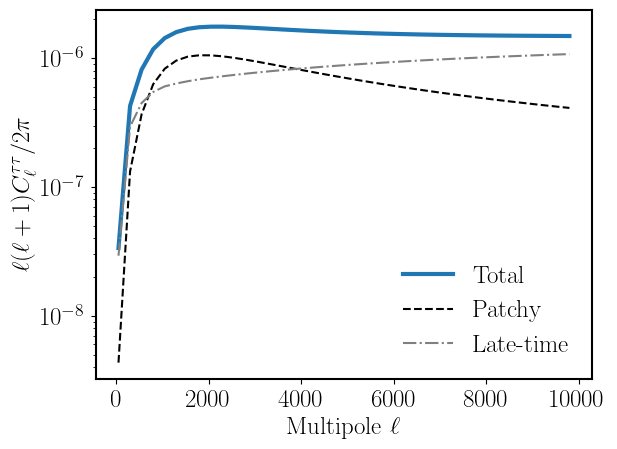

In [15]:
plt.figure()
plt.semilogy(ells, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### 21cm power spectrum

To compute the 21cm power spectrum, use the `get_p21(k,z)` method.

In [16]:
zarr = np.linspace(5., 10, 20)
karr = np.logspace(-4, 2, 100)

ps_21 = model.get_p21(karr, zarr[:, None], mK=True, log=False, pk_units=True)

Text(0, 0.5, 'Reionisation history')

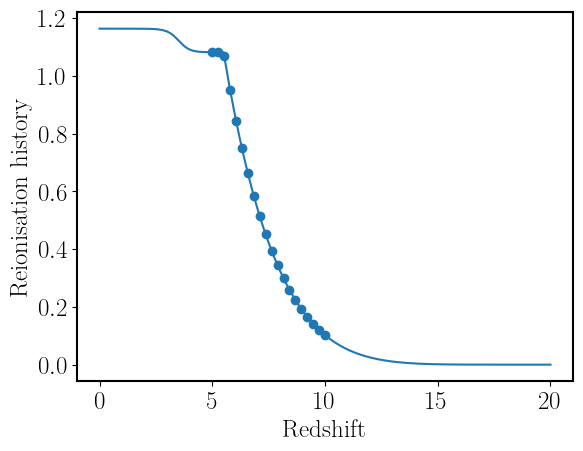

In [17]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, model.xe(z))
plt.scatter(zarr, model.xe(zarr))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

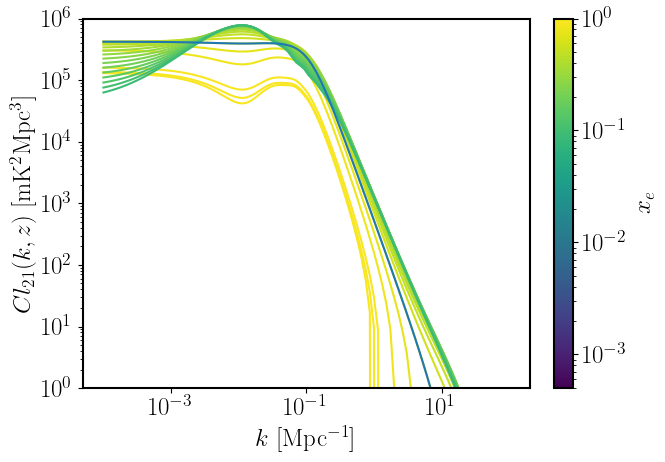

In [18]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

fig, ax = plt.subplots()
for iz, z in enumerate(zarr):
    ax.loglog(karr, ps_21[iz], color=cmap(norm(model.xe(z)[0]/model.f)))
ax.plot(karr, ps_21[5])
ax.set_ylim(1e0, 1e6)
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$Cl_{21}(k, z)$ [mK$^2$Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

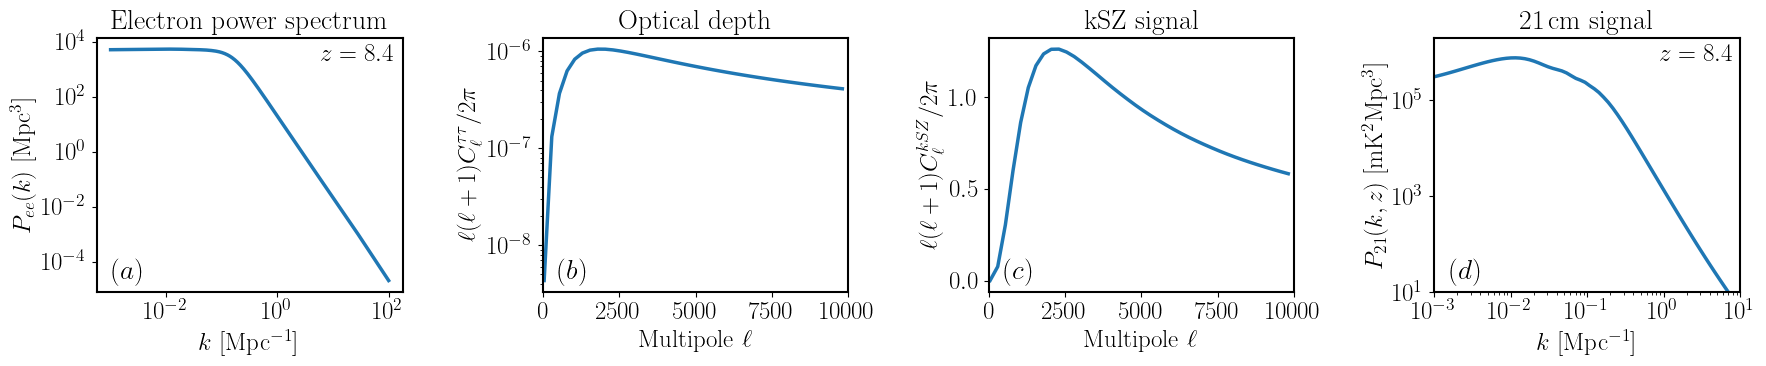

In [19]:
zref = 8.4
props = dict(boxstyle="round", facecolor="white", alpha=0.5)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
# pee
axes[0].loglog(klog, model.Pee(klog, zref), lw=2.5)
axes[0].set_xlabel(r'$k$ [Mpc$^{-1}$]')
axes[0].set_ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
axes[0].text(6, 2000, rf'$z={zref:.1f}$')#, bbox=props)
# tau
axes[1].semilogy(ells, tau_ps[:, 0], ls='-', color='C0', lw=2.5)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# axes[1].set_ylim(bottom=1e-5)
axes[1].set_xlim(0, 10000)

# ksz
axes[2].plot(ells, ksz_ps[:, 0], lw=2.5)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
axes[2].set_xlim(0, 10000)

# 21cm ps
axes[3].loglog(karr, model.get_p21(karr, zref, mK=True, log=False, pk_units=True), lw=2.5)
axes[3].set_ylim(bottom=1e0)
axes[3].set_xlabel(r'$k$ [Mpc$^{-1}]$')
axes[3].set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
axes[3].set_xlim(1e-3, 10)
axes[3].set_ylim(10, 2e6)
axes[3].text(.9, 6.5e5, rf'$z={zref:.1f}$')#, bbox=props)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', '21\,cm signal'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].text(0.05, 0.05, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20)
fig.tight_layout()
# fig.savefig('model2observables_ps.pdf', dpi=220)

### Primary power spectra

The class also computes primary power spectra:

In [20]:
CMB_Cells = model.get_primary_spectra(ells=np.linspace(1, 500))

 Computing CMB power spectra...


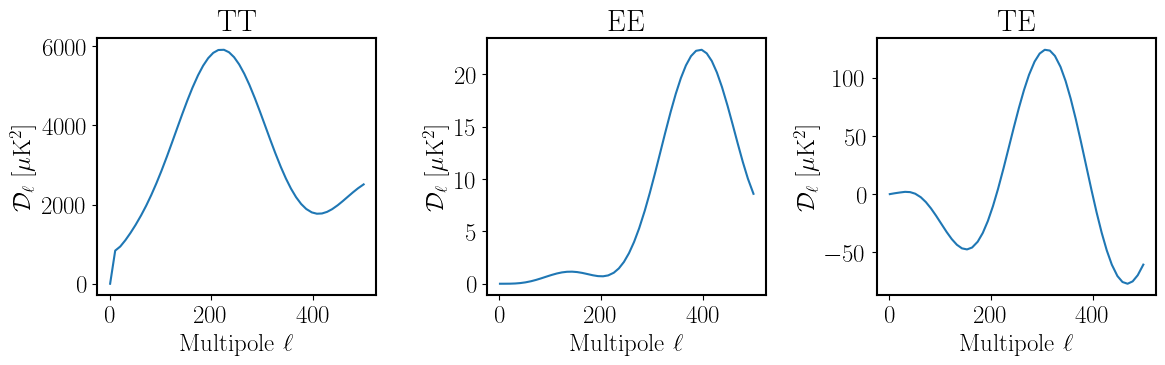

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for u, (ax, label) in enumerate(zip(axes,
                                   [ 'TT', 'EE', 'TE'])):
    ax.plot(CMB_Cells[:, 0], CMB_Cells[:, u+1])
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
    ax.set_title(label)
    ax.set_xlabel(r'Multipole $\ell$')
fig.tight_layout()

## Make Gaussian boxes from power spectra

From these power spectra, we can generate Gaussian random boxes (with corresponding power spectrum). We work in the flat-sky approximation and identify the angular power spectrum with the Fourier power spectrum, following $k \sim 2\ell / d_c(z)$.

In [26]:
from simulations import gaussian_box_from_ps, gaussian_box_from_cl

In [27]:
ndim = 3
N = 512
fov = 5. * units.deg

In [28]:
size = tuple([N for i in range(ndim)])
phases = np.random.random(size) * 2. * np.pi

In [29]:
iz = 8
L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
print(zarr[iz], model.xe(zarr[iz]), L21)

7.105263157894736 [0.51376596] 772.6277414014246


6.052631578947368 [0.84538684]


Text(0, 0.5, '$\\mathcal{D}_\\ell$ [$\\mu$K$^2$]')

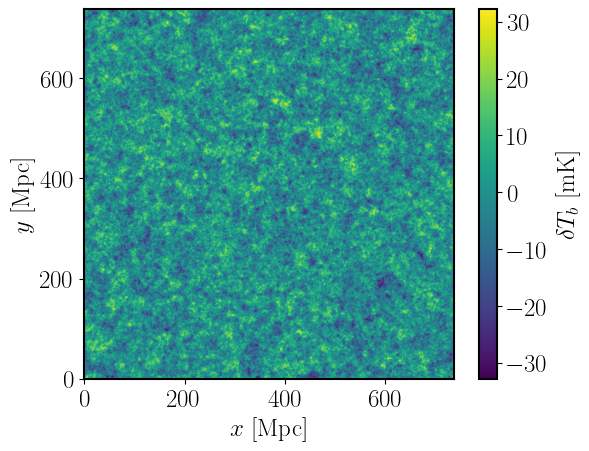

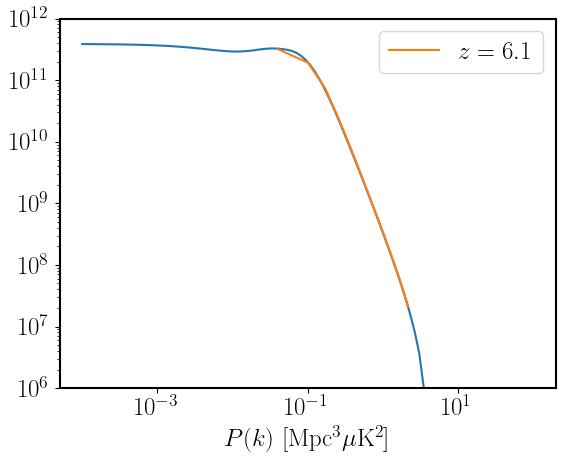

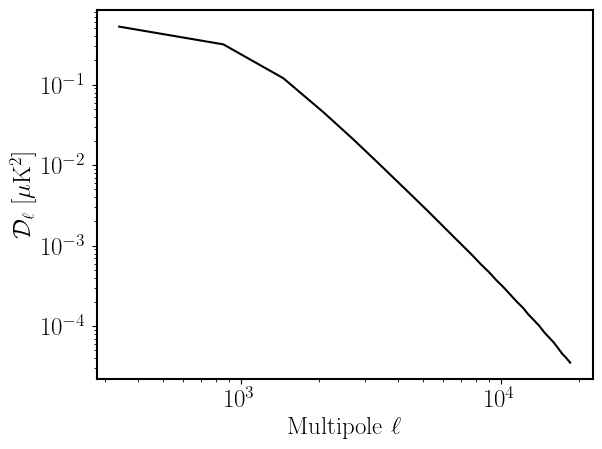

In [30]:
iz = 4
L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
print(zarr[iz], model.xe(zarr[iz]))
pk_array = np.c_[karr, ps_21[iz] * 1e6].T   # muK2
box_21 = gaussian_box_from_ps(N, L21, pk_array, ndim=ndim, phases=phases)

fig, ax = plot_field(box_21/1000, L21, label=r'$\delta T_b$ [mK]')
ks, pks, es = compute_ps1d(box_21, L21)

plt.figure()
plt.loglog(pk_array[0], pk_array[1])
plt.plot(ks, pks, label=rf'$z={zarr[iz]:.1f}$')
plt.ylim(1e6, 1e12)
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.xlabel(r'$P(k)$ [Mpc$^3 \mu$K$^2$]')
plt.legend()

ls, cls, erls = compute_cl_from_box(box_21, fov.to(units.rad).value, nbins=30)
# print(cls)
plt.figure()
# plt.plot(pk_array[0], pk_array[1])
plt.loglog(ls[cls>0.], cls[cls>0.], color='k')
# ls, cls, erls = compute_ps1d(cmb_box, fov2.to(units.rad).value * cos.comoving_distance(zobs_cmb).value, nbins=20)
# plt.plot(ls[cls>0.]*cos.comoving_distance(zobs_cmb).value, cls[cls>0.]/1e7)
# plt.xlim(0, 1000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
# print(ls)


In [31]:
# integrated 21cm signal
dTb_maps = np.zeros((zarr.size, N, N, N), dtype=float)
for iz in tqdm(range(zarr.size)):
    L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
    pk_array = np.c_[karr, ps_21[iz] * 1e6].T  # muK2
    dTb_maps[iz] = gaussian_box_from_ps(N, L21, pk_array, ndim=ndim, phases=phases)

100%|██████████| 20/20 [10:26<00:00, 31.34s/it]


In [32]:
int_21cm = np.trapz(np.array(dTb_maps), zarr, axis=0)

Text(0.5, 1.0, 'Integrated 21cm signal')

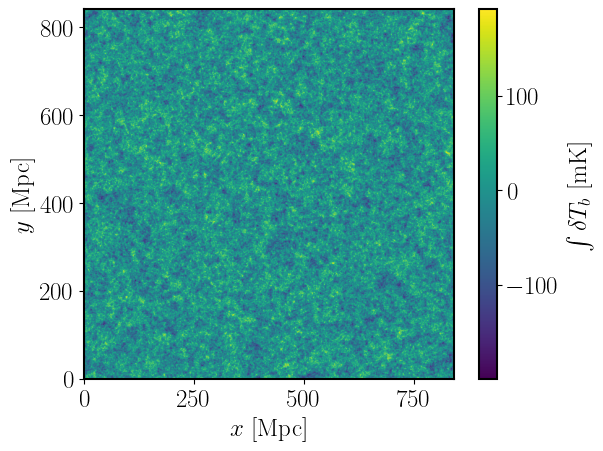

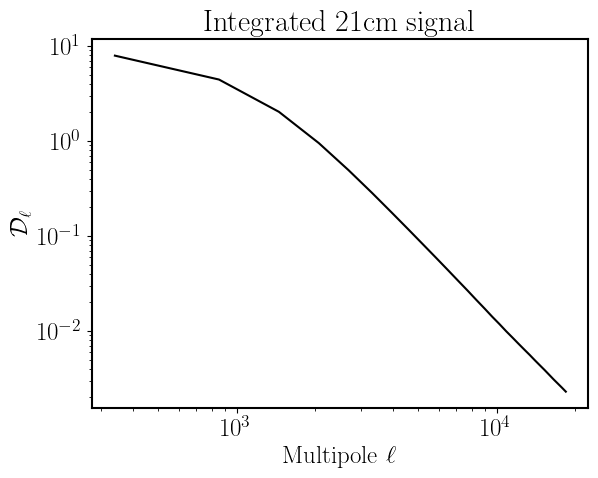

In [33]:
fig, ax = plot_field(int_21cm/1000, L21, label=r'$\int \delta T_b$ [mK]')

ls, cls, erls = compute_cl_from_box(int_21cm, fov.to(units.rad).value, nbins=30)
plt.figure()
plt.loglog(ls[cls>0.], cls[cls>0.], color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$')
plt.title('Integrated 21cm signal')

0.4285714285714286 0.09765625 deg 0.05285483163838915
2.781108676686017e-14


Text(0, 0.5, '$P(k)$ [Mpc$^3$]')

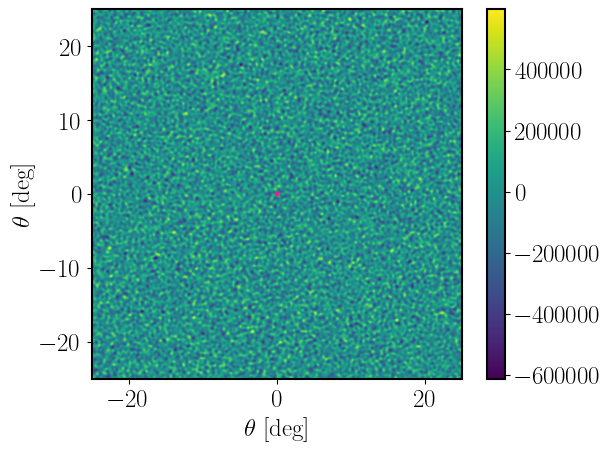

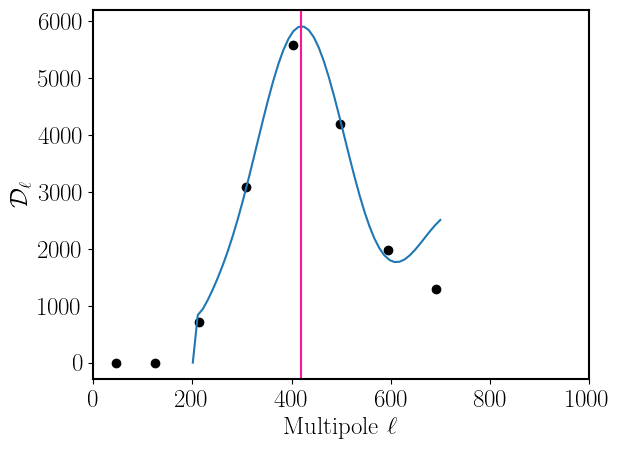

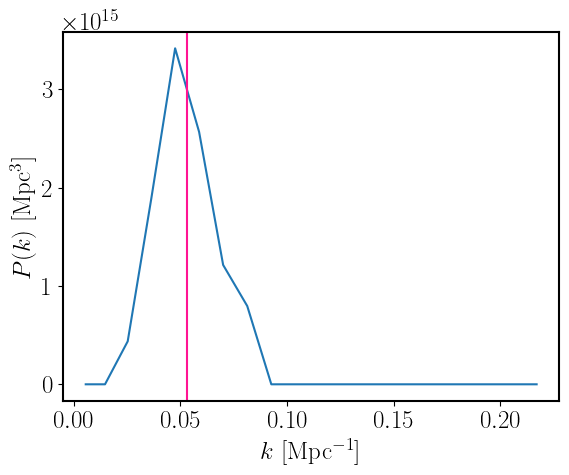

In [34]:
fov2 = 10.*fov
zobs_cmb = 5.

ref_multipole = 220. +200.
ref_theta = (np.pi/ref_multipole)*(180./np.pi)
ref_kx = ref_multipole/cos.comoving_distance(zobs_cmb).value
print(ref_theta, fov2.to(units.deg)/N, ref_kx)

pk_array = np.copy(CMB_Cells[:, :2].T)
pk_array[0] += 200
cmb_box = gaussian_box_from_cl(N, fov2.to(units.rad).value, pk_array, ndim=3)

# physical box
fig, ax = plot_field_theta(cmb_box, fov2.to(units.deg).value,)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,#fov2.to(units.deg).value/N,#ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)
print(np.mean(cmb_box))

# angular power spectrum
ls, cls, erls = compute_cl_from_box(cmb_box, fov2.to(units.rad).value, nbins=20)
plt.figure()
plt.plot(pk_array[0], pk_array[1])
plt.axvline(ref_multipole, color='deeppink')
plt.scatter(ls[cls>0.], cls[cls>0.], color='k')
# ls, cls, erls = compute_ps1d(cmb_box, fov2.to(units.rad).value * cos.comoving_distance(zobs_cmb).value, nbins=20)
# plt.plot(ls[cls>0.]*cos.comoving_distance(zobs_cmb).value, cls[cls>0.]/1e7)
plt.xlim(0, 1000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$')
# print(ls)

# cartesian power spectrum
ks, pks, err_pks = compute_ps1d(cmb_box, np.tan(fov2.to(units.rad).value/2.) *2. *  cos.comoving_distance(zobs_cmb).value, nbins=20)
plt.figure()
plt.plot(ks, pks)
plt.axvline(ref_kx, color='deeppink')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P(k)$ [Mpc$^3$]')


(0.0, 10000.0)

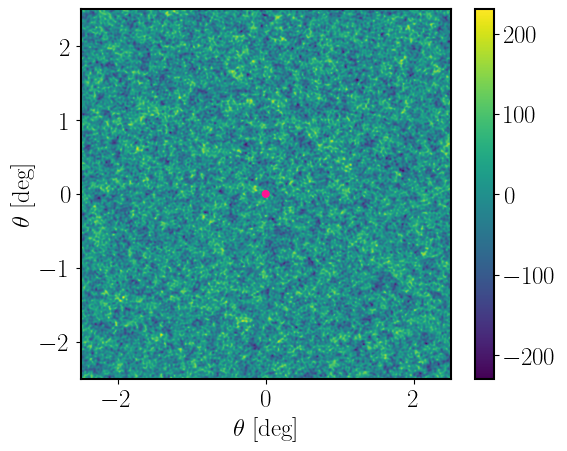

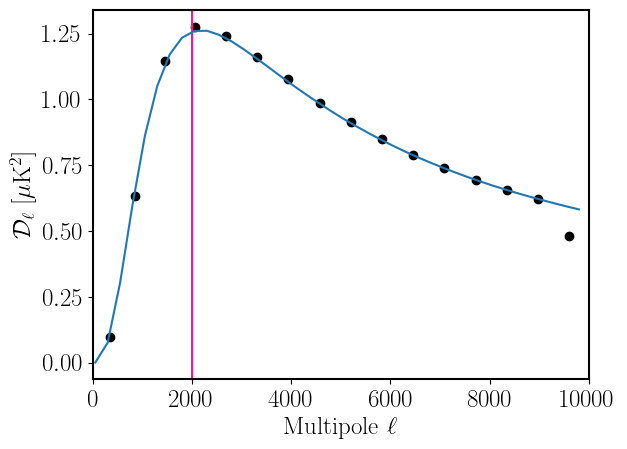

In [35]:
pk_array = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

ksz_box = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array, ndim=ndim, phases=phases)
fig, ax = plot_field_theta(ksz_box, fov.to(units.deg).value)
ref_multipole = 2000.
ref_theta = (np.pi/ref_multipole)*(180./np.pi)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)

ls, cls, erls = compute_cl_from_box(ksz_box, fov.to(units.rad).value)

plt.figure()
plt.axvline(ref_multipole, color='deeppink')
plt.plot(pk_array[0], pk_array[0]*(pk_array[0]+1.)*pk_array[1]/2./np.pi)
plt.scatter(ls, ls*(ls+1.)*cls/2./np.pi, color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 10000)

(0.0, 10000.0)

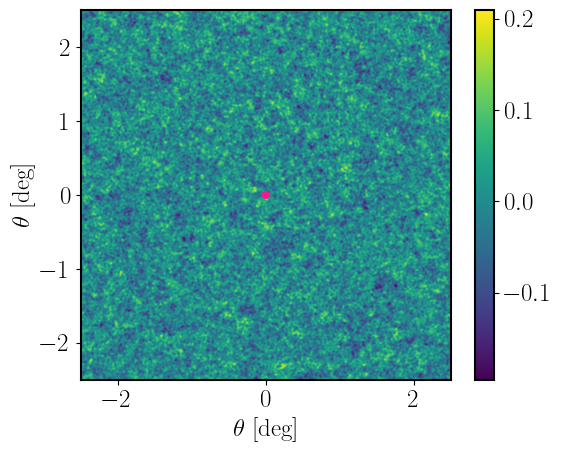

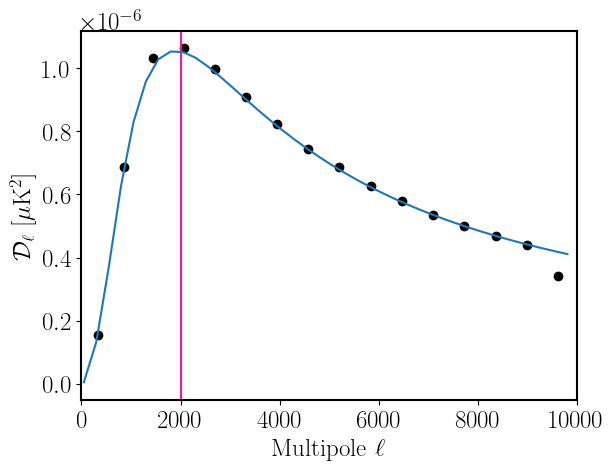

In [36]:
# pk_array = np.c_[ells, (tau_ps[:, 0]+tau_ps[:, 1])/ells/(ells + 1)*2.0*np.pi/(model.T_cmb * 1e6) ** 2].T
pk_array = np.c_[ells, tau_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

tau_box = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array, ndim=ndim, phases=phases)
fig, ax = plot_field_theta(tau_box, fov.to(units.deg).value)
# ref_theta = (np.pi/3000.)*(180./np.pi)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)

ls, cls, erls = compute_cl_from_box(tau_box, fov.to(units.rad).value)

plt.figure()
plt.axvline(ref_multipole, color='deeppink')
plt.plot(pk_array[0], pk_array[0]*(pk_array[0]+1.)*pk_array[1]/2./np.pi)
plt.scatter(ls, ls*(ls+1.)*cls/2./np.pi, color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 10000)

## With `healpy`

In [ ]:
import healpy as hp

In [ ]:
hp_ls = np.arange(int(ells.max()))

### kSZ map

In [109]:
interp_ksz = interp1d(ells, ksz_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
ksz_map = hp.synfast(interp_ksz(hp_ls), nside=2048, )# uK
ksz_map /= 1e3 #mK
ksz_ps2 = hp.anafast(ksz_map)

In [110]:
lrange = np.arange(ksz_ps2.size)

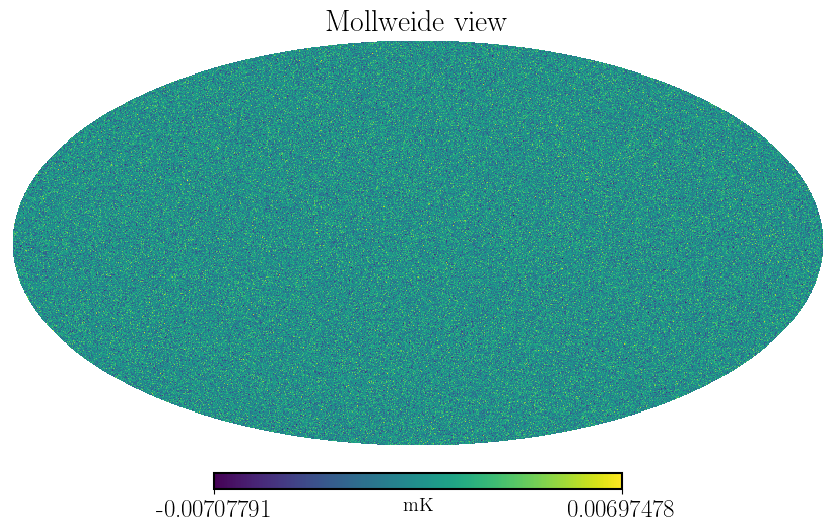

In [111]:
hp.mollview(ksz_map, unit='mK')

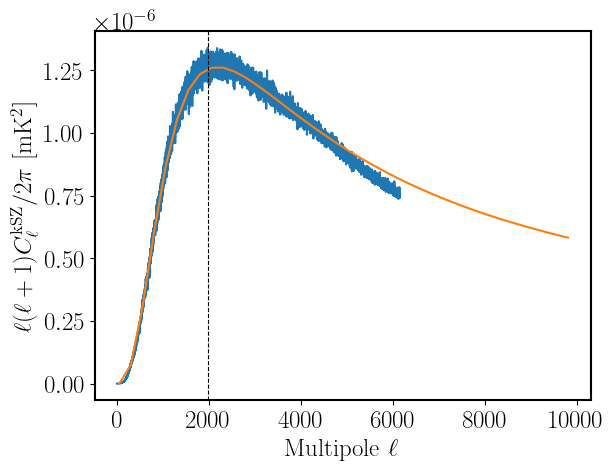

In [112]:
slope, intercept = 6.292754846642347e-05, -0.024391080262949116

plt.figure()
plt.plot(lrange, ksz_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, ksz_ps[:, 0]/1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}}/2\pi$ [mK$^2$]')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


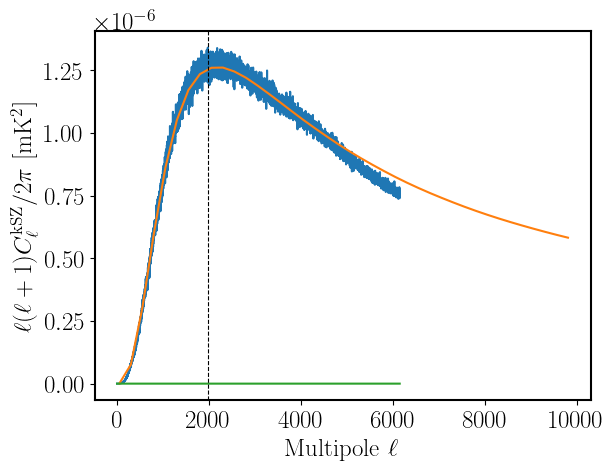

In [113]:
ksz2_ps = hp.anafast(ksz_map**2)
plt.figure()
plt.plot(lrange, ksz_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, ksz_ps[:, 0]/1e6)
plt.plot(lrange, ksz2_ps*lrange*(lrange+1)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}}/2\pi$ [mK$^2$]')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


### $\tau$ map

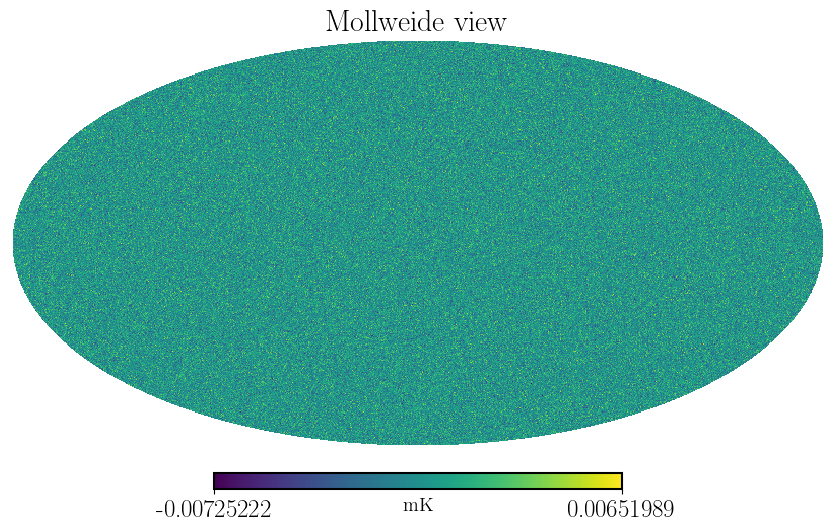

In [114]:
interp_tau = interp1d(ells, tau_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
tau_map = hp.synfast(interp_tau(hp_ls), nside=2048, ) #mK

hp.mollview(tau_map, unit='mK')


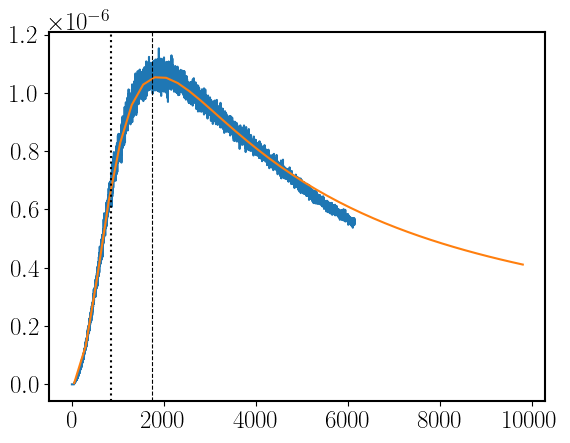

In [115]:
tau_ps2 = hp.anafast(tau_map)
slope, intercept = 6.292754846642347e-05, -0.01
plt.figure()
plt.plot(lrange, tau_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, tau_ps[:, 0])
plt.axvline(model.kappa*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


### 21cm power spectrum

In [273]:
from scipy.special import spherical_jn as jn

In [264]:
iz = 5
print(zarr[iz], model.xe(zarr[iz]))

6.315789473684211 [0.74912034]


$P_{2D}(k_\perp) = \int \mathrm{d}k\, P_{3D}(k_\perp, k_\parallel)$

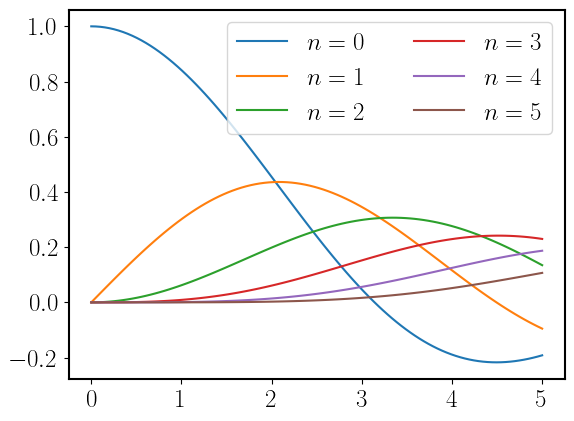

In [276]:
xlin = np.linspace(0, 5, 100)
for n in np.arange(0,6):
    plt.plot(xlin, jn(n, xlin), label=fr'$n={n}$')
plt.legend(ncols=2)

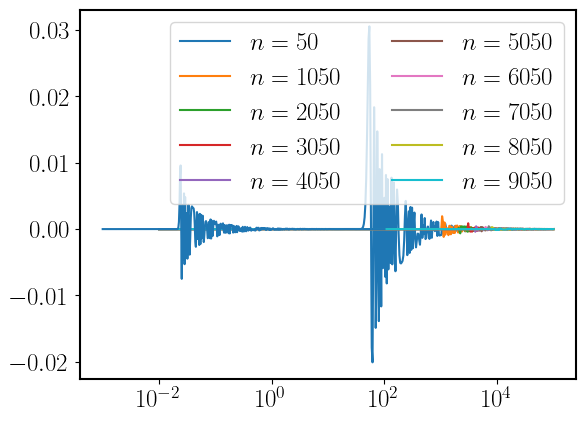

In [275]:
xlin = np.logspace(-2, 5, 500)
for n in ells[::4]:
    plt.semilogx(xlin, jn(int(n), xlin), label=fr'$n={n}$')
plt.legend(ncols=2)
plt.semilogx(klog, jn(200, klog*cos.comoving_distance(zarr[iz]).value)) 

In [274]:
Jarr = jn(np.array(ells, dtype=int)[:, None], karr*cos.comoving_distance(zarr[iz]).value)**2
print(Jarr.shape)

(40, 100)


In [121]:
xlin = np.linspace(0.1, 10., 100)
print(np.trapz(xlin**2, xlin))
xlog = np.logspace(-1, 1, 100)
print(np.trapz(xlog**2, xlog))

333.34950000000003
333.4531470637125


$C_\ell = \frac{2}{\pi} \int k^2 \mathrm{d}k\, P(k) j_\ell[k d_c(z)]$

5.432597655714892e-07 4.9419589223943e-07


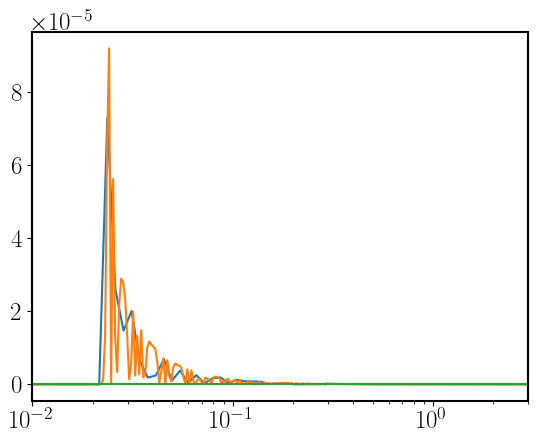

In [122]:
plt.figure()
# plt.plot(karr, karr**2 * ps_21[iz])
ell = 200
plt.semilogx(karr, jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2)
plt.semilogx(klog, jn(int(ell), klog*cos.comoving_distance(zarr[iz]).value)**2)    
plt.semilogx(klog, jn(int(ell), klog)**2)    
plt.xlim(1e-2, 3)
print(np.trapz(jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2, karr), np.trapz(jn(int(ell), klog*cos.comoving_distance(zarr[iz]).value)**2, klog))

(0.0, 3000.0)

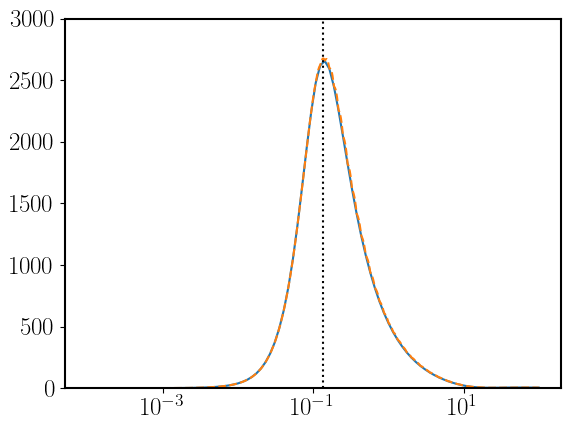

In [271]:
ps_21_interp = interp1d(karr, ps_21[iz], fill_value='extrapolate', bounds_error=False)

plt.figure()
ell = 200
plt.semilogx(karr, karr**2 * ps_21[iz])
plt.semilogx(klog, klog**2 * ps_21_interp(klog), ls='--')
# plt.axvline(model.kappa)
plt.axvline(model.kappa/model.xe(zarr[iz]), color='k', ls=':')
# plt.axhline(10**(model.alpha0)/2.)
plt.ylim(0, 3000)

(0.01, 1.0)

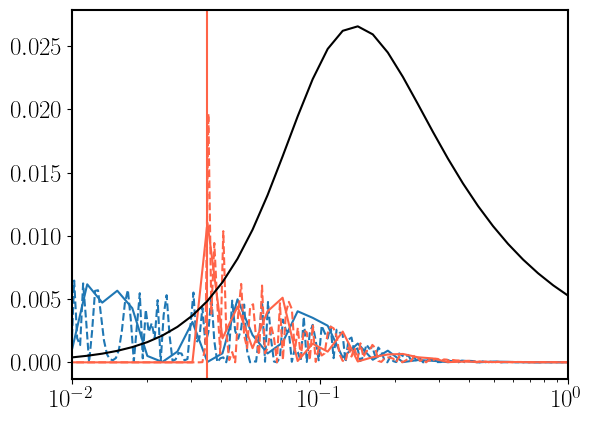

In [277]:
ell = 200
klog2 = np.logspace(np.log10(karr.min()), np.log10(karr.max()), 500)
plt.figure()
for u, (ell, color) in enumerate(zip(ells[:2], ['C0', 'tomato'])):
    plt.semilogx(karr, karr**2 * ps_21[iz] * jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2, color=color, ls='-')
    plt.semilogx(klog2, klog2**2 * ps_21_interp(klog2) * jn(int(ell), klog2*cos.comoving_distance(zarr[iz]).value)**2, color=color, ls='--')
    keta = (ell+0.5)/cos.comoving_distance(zarr[iz]).value
    # plt.axhline(keta**2 * ps_21_interp(keta) * np.pi/(2*ell+1.), color=color, ls='--')
    plt.axvline(keta, color=color)
plt.semilogx(karr, karr**2 * ps_21[iz] *1e-5, color="k", ls='-')
plt.xlim(1e-2, 1e0)


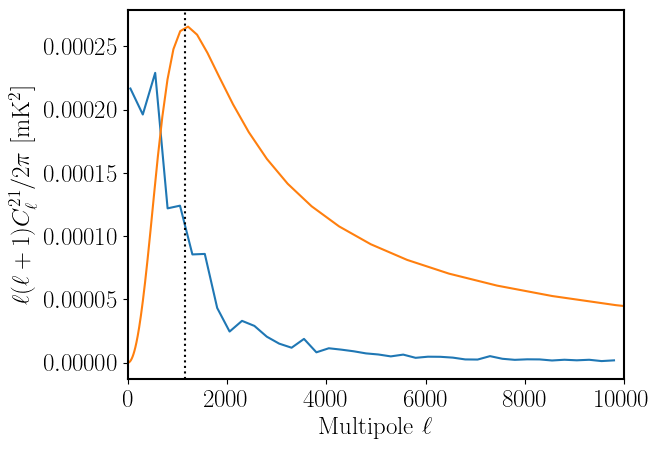

In [278]:
# iz = 4
# print(zarr[iz], model.xe(zarr[iz]))
cls_21 = ps_21[iz] * karr**2 
# cls_21 = 2./np.pi * np.trapz(karr**2 * ps_21[iz] * jn(np.array(ells, dtype=int)[:, None], karr*cos.comoving_distance(zarr[iz]).value), karr, axis=1)
cls_212 = 2./np.pi * np.trapz(klog2**2 * ps_21_interp(klog2) * jn(np.array(ells, dtype=int)[:, None], klog2*cos.comoving_distance(zarr[iz]).value)**2, klog2, axis=1)

ells_21 = karr * cos.comoving_distance(zarr[iz]).value

plt.figure()
# plt.semilogy(ells_21, cls_21)#*(ells_21+1)*ells_21/2./np.pi)
plt.plot(ells, cls_212)#*(ells_21+1)*ells_21/2./np.pi)
plt.plot(ells_21, cls_21 / 1e7)
# plt.semilogy(ells_21, cls_21)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{21}/2\pi$ [mK$^2$]')
plt.xlim(0, 10000)
plt.axvline(model.kappa/model.xe(zarr[iz])*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
# plt.plot(hp_ls, interp_p21(hp_ls))


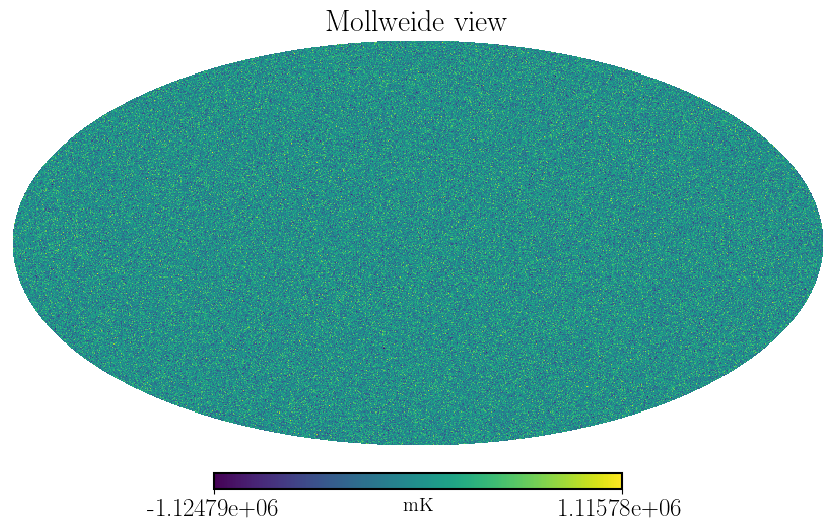

In [279]:
cls_21 = ps_21[iz] #* karr**2 
interp_p21 = interp1d(ells_21, cls_21, fill_value=0, bounds_error=False)
dTb_map = hp.synfast(interp_p21(hp_ls), nside=2048, )
p21_cls2 = hp.anafast(dTb_map)

hp.mollview(dTb_map, unit='mK')


Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell^{21}/2\\pi$ [mK$^2$]')

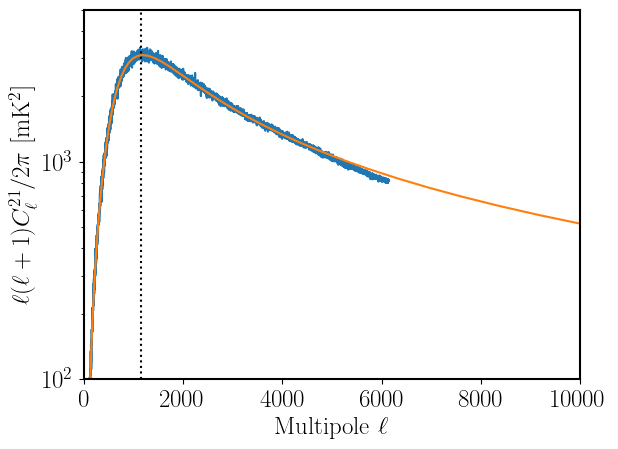

In [127]:
plt.figure()
plt.semilogy(lrange, p21_cls2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells_21, cls_21*(ells_21+1)*ells_21/2./np.pi/1e7)
plt.axvline(model.kappa/model.xe(zarr[iz])*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
# plt.ylim(1e0, 1e3)
plt.ylim(1e2, 5e3)
plt.xlim(0, 10000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{21}/2\pi$ [mK$^2$]')